<a href="https://colab.research.google.com/github/Priyanshuthapliyal2005/IrisFlowerNaiveBayes/blob/main/irisFlowerNaiveBayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [119]:
import pandas as pd
import os

In [120]:
%pwd

'/content/Iris'

In [121]:
!mkdir Iris

mkdir: cannot create directory ‘Iris’: File exists


In [122]:
!ls

Iris


In [123]:
path = "/content/Iris"

In [124]:
%pwd

'/content/Iris'

In [125]:
os.chdir("/content/Iris")

In [126]:
%pwd

'/content/Iris'

In [127]:
import kagglehub
import shutil

download_path = kagglehub.dataset_download("shantanuss/iris-flower-dataset")

destination_path = os.getcwd()
shutil.move(download_path, destination_path)

print("Dataset moved to:", destination_path)
!ls

Dataset moved to: /content/Iris
1  Iris


In [128]:
%pwd

'/content/Iris'

In [129]:
data=pd.read_csv('1/Iris_flower_dataset.csv')

In [130]:
data.head()


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [131]:
data.dtypes

,0
Id,int64
SepalLengthCm,float64
SepalWidthCm,float64
PetalLengthCm,float64
PetalWidthCm,float64
Species,object


In [132]:
data.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [133]:
from sklearn.preprocessing import scale

In [134]:
features=scale(data[['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']])

In [135]:
pd.DataFrame(features).describe()

,0,1,2,3
count,1.500000e+02,1.500000e+02,1.500000e+02,1.500000e+02
mean,-4.736952e-16,-6.631732e-16,3.315866e-16,-2.842171e-16
std,1.003350e+00,1.003350e+00,1.003350e+00,1.003350e+00
min,-1.870024e+00,-2.438987e+00,-1.568735e+00,-1.444450e+00
25%,-9.006812e-01,-5.877635e-01,-1.227541e+00,-1.181504e+00
50%,-5.250608e-02,-1.249576e-01,3.362659e-01,1.332259e-01
75%,6.745011e-01,5.692513e-01,7.627586e-01,7.905908e-01
max,2.492019e+00,3.114684e+00,1.786341e+00,1.710902e+00


In [136]:
target=data['Species']

In [137]:
target.value_counts()

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [138]:
from sklearn.preprocessing import LabelEncoder

In [139]:
target=pd.Series(LabelEncoder().fit_transform(target))

In [140]:
target.value_counts()

,count
0,50
1,50
2,50


In [141]:
from sklearn.model_selection import train_test_split

In [142]:
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.4, random_state=42)

In [143]:
print(f"Training set size: {len(x_train)} samples")
print(f"Test set size: {len(x_test)} samples")

Training set size: 90 samples
Test set size: 60 samples


In [144]:
print(len(x_train))
print(len(y_train))
print(len(x_test))
print(len(y_test))

90
90
60
60


In [145]:
from sklearn.naive_bayes import GaussianNB

In [146]:
bc=GaussianNB()

In [147]:
bc.fit(x_train,y_train)

GaussianNB()

In [148]:
pred=bc.predict(x_test)

In [149]:
from sklearn.metrics import precision_score,recall_score,f1_score,classification_report,accuracy_score

In [150]:
print('Model Performance Metrics (100% Data):')
print('------------------------------------')
print(f'Accuracy: {accuracy_score(pred, y_test) * 100:.2f}%')
print(f'Precision: {precision_score(pred, y_test, average="weighted") * 100:.2f}%')
print(f'Recall: {recall_score(pred, y_test, average="weighted") * 100:.2f}%')
print(f'F1-score: {f1_score(pred, y_test, average="weighted") * 100:.2f}%')


Model Performance Metrics (100% Data):
------------------------------------
Accuracy: 96.67%
Precision: 96.67%
Recall: 96.67%
F1-score: 96.67%


In [151]:
print('\nDetailed Classification Report:')
print('------------------------------')
print(classification_report(y_test, pred))


Detailed Classification Report:
------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       0.95      0.95      0.95        19
           2       0.94      0.94      0.94        18

    accuracy                           0.97        60
   macro avg       0.96      0.96      0.96        60
weighted avg       0.97      0.97      0.97        60



Text(0.5, 58.7222222222222, 'Predicted Label')

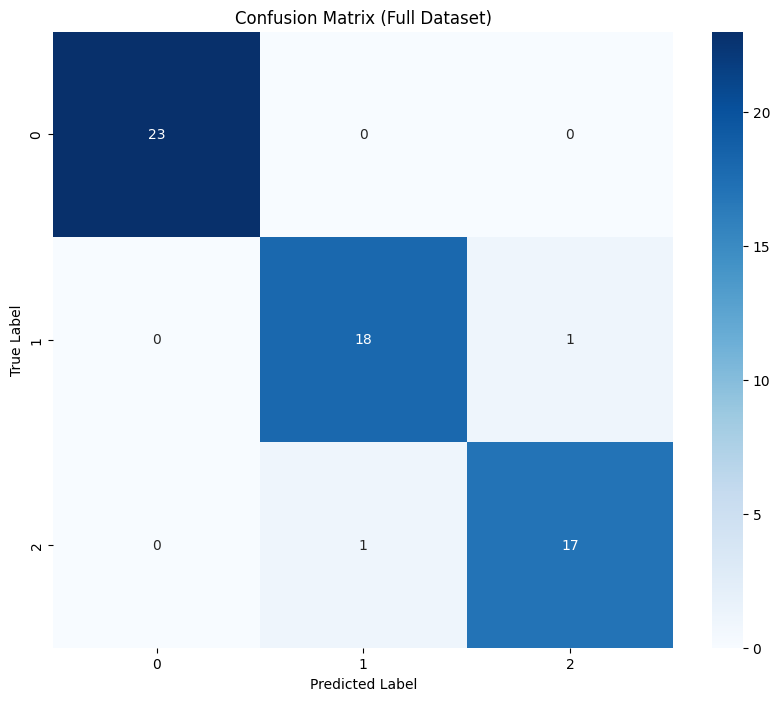

In [152]:
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Full Dataset)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

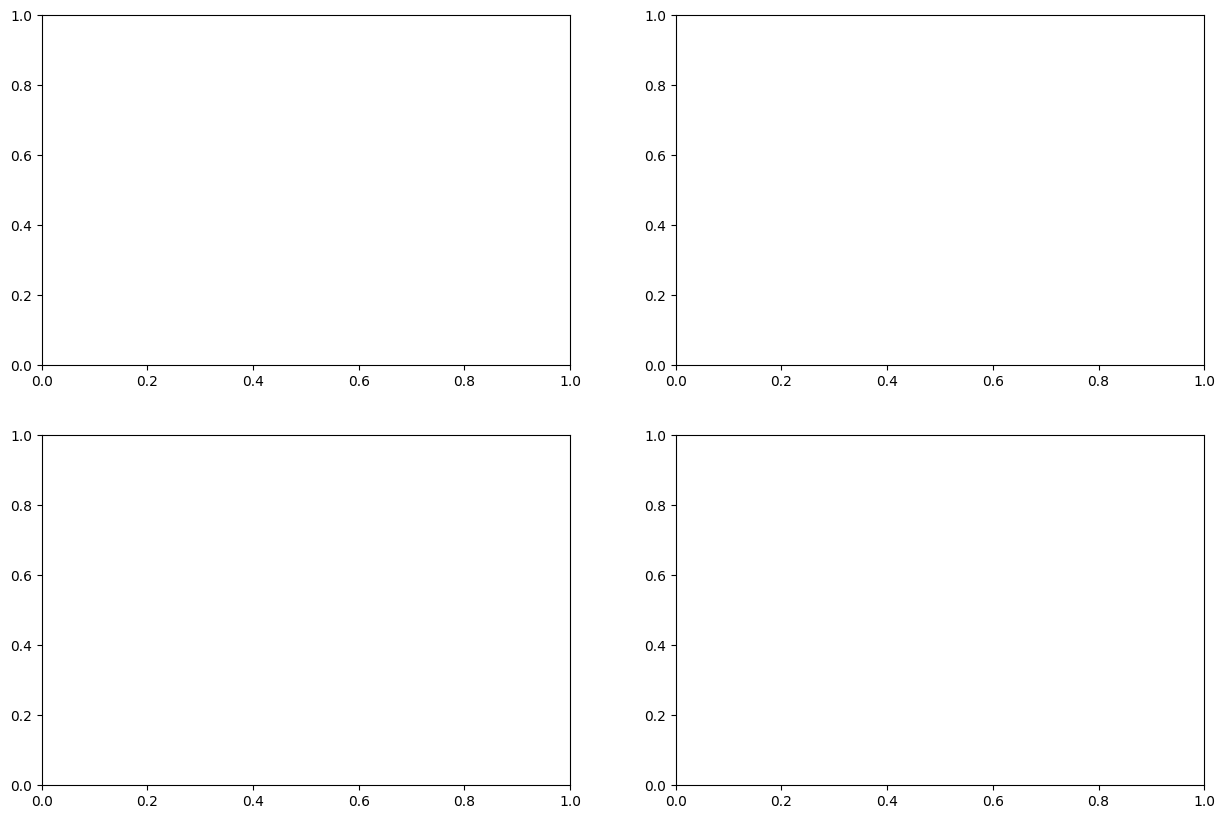

In [153]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

In [154]:
features_df = pd.DataFrame(features, columns=['sepal_length', 'sepal_width',
                                            'petal_length', 'petal_width'])
features_df['species'] = target

In [155]:
for idx, feature in enumerate(features_df.columns[:-1]):
    row = idx // 2
    col = idx % 2
    sns.boxplot(data=features_df, x='species', y=feature, ax=axes[row, col])
    axes[row, col].set_title(f'{feature} Distribution by Class')


In [156]:
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

Text(0.5, 1.0, 'Feature Correlation Matrix')

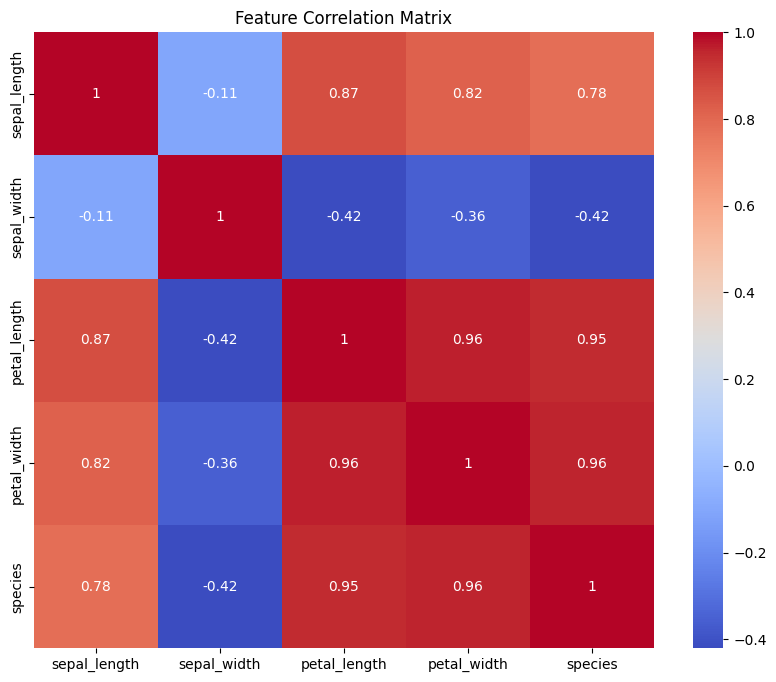

In [157]:
plt.figure(figsize=(10, 8))
correlation_matrix = features_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')

Text(0.5, 1.02, 'Pairwise Feature Relationships')

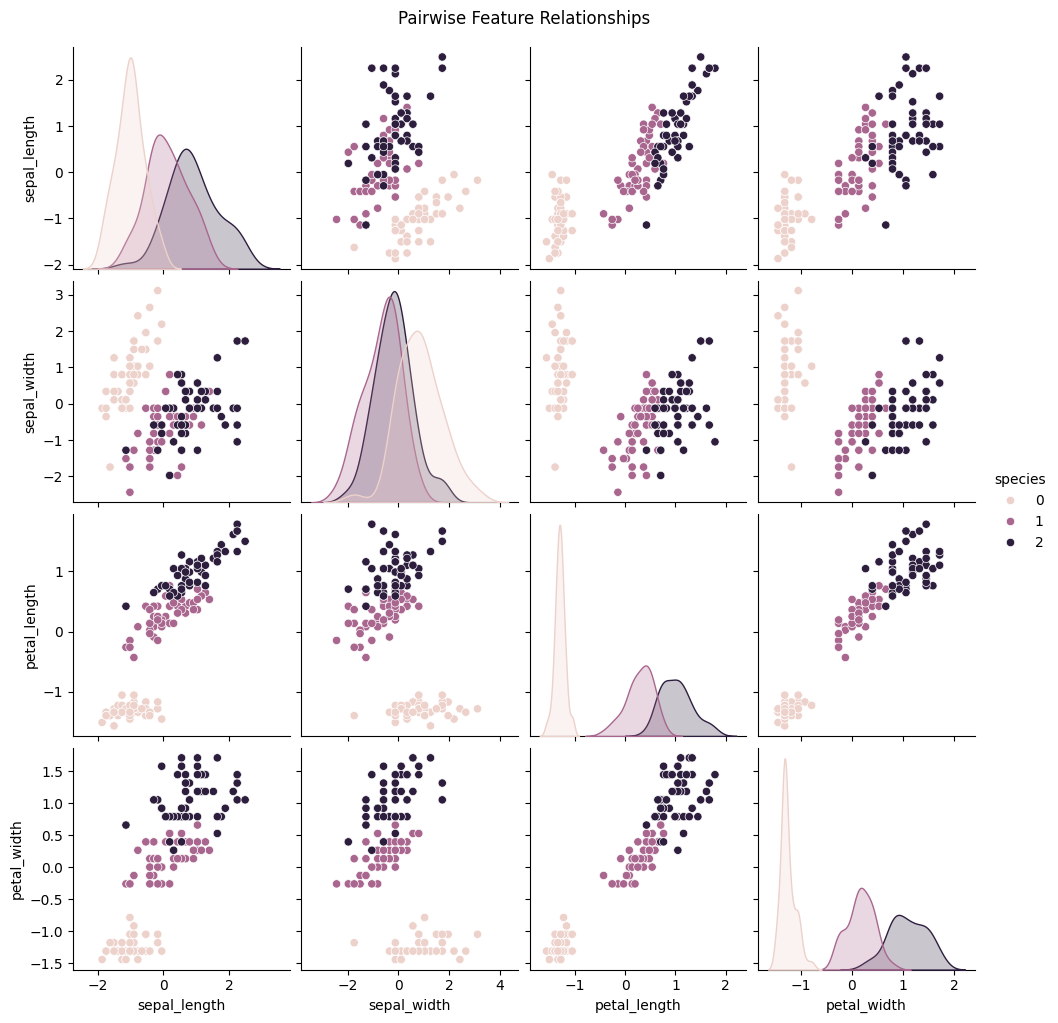

In [158]:
sns.pairplot(features_df, hue='species')
plt.suptitle('Pairwise Feature Relationships', y=1.02)
